<a href="https://colab.research.google.com/github/PyGhosh/Grp_CH4124/blob/main/Group-A/Home-Assignment-1/230122020_HA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Instructions

Complete every code location marked **`TODO`**. Run the notebook from top to bottom after completing each section.

By the end of this exercise, you should be able to:

1. implement centroid initialization, assignment, and update steps in K-means;
2. calculate distortion and the silhouette score;
3. compare a from-scratch implementation with scikit-learn;
4. implement the E-step and M-step of a Gaussian Mixture Model (GMM);
5. monitor log-likelihood and use it as a convergence criterion.

**Rules:** Do not call `sklearn.cluster.KMeans` inside the from-scratch K-means class, and do not call `sklearn.mixture.GaussianMixture` inside the from-scratch GMM class. Small numerical constants such as `1e-9` may be added when needed for stability.

## a) Clustering using K-means

### Program 1 - Implementing K-means Clustering from scratch and using scikit learn

#### AIM

To implement K-means clustering from scratch, evaluate the resulting clusters, and compare the implementation with scikit-learn.

#### K-means algorithm

1. Select $k$ observations as the initial centroids.
2. Assign every observation to its nearest centroid.
3. Replace each centroid by the mean of the observations assigned to it.
4. Repeat steps 2–3 until the centroids stop changing (or a maximum number of iterations is reached).

#### Distortion

In this exercise, distortion is the mean Euclidean distance between every observation and its assigned centroid:

$$D = \frac{1}{N}\sum_{i=1}^{N}\lVert\mathbf{x}_i-\boldsymbol{\mu}_{z_i}\rVert_2.$$

#### Silhouette score

For observation $i$, let $a(i)$ be its mean distance to the other points in its own cluster and let $b(i)$ be the smallest mean distance from it to any other cluster. Then

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}, \qquad S=\frac{1}{N}\sum_i s(i).$$

A score near $1$ indicates well-separated clusters, while a score near $-1$ indicates that many observations may be assigned to the wrong cluster.

#### Part 1 - Defining class for KMeans

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.set_printoptions(precision=4, suppress=True)

In [2]:
class KMeans:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, train_x, random_state=0):
        m = train_x.shape[0]
        rng = np.random.default_rng(random_state)

        # TODO 1: Select `n_clusters` distinct observations as initial centroids.
        # Hint: rng.choice(..., replace=False)
        indices = rng.choice(m, size = self.n_clusters, replace = False)
        self.centroids = train_x[indices]


        for iteration in range(self.max_iter):
            old_centroids = self.centroids.copy()

            # TODO 2: Assign each training observation to its nearest centroid.
            distance_from_each_centroid = cdist(train_x, self.centroids)
            self.labels = np.argmin(distance_from_each_centroid, axis = 1)

            # TODO 3: Update each centroid using the mean of its assigned points.
            # Keep the old centroid if a cluster receives no observations.
            for cluster_id in range(self.n_clusters):
                cluster_points = train_x[self.labels == cluster_id]
                if len(cluster_points) > 0:
                    self.centroids[cluster_id] = np.mean(cluster_points, axis = 0)


            # TODO 4: Stop when the centroid displacement is at most `self.tol`.
            # Hint: np.linalg.norm(self.centroids - old_centroids)
            if np.linalg.norm(self.centroids - old_centroids) <= self.tol:
                self.converged = True
                break

        self.n_iter_ = iteration + 1
        return self

    def predict(self, points):
        # TODO 5: Calculate point-to-centroid distances and return the index
        # of the nearest centroid for every point.
        distance_from_each_centroid = cdist(points, self.centroids)
        return np.argmin(distance_from_each_centroid, axis = 1)

#### Part 2 — Defining evaluation metrics

Complete both functions without calling their scikit-learn equivalents. Test the edge cases: a single cluster, a singleton cluster, and more than two clusters.

In [3]:
def distortion(X, labels, centroids):
    # TODO 6: Select the assigned centroid for every observation and return
    # the mean Euclidean distance to that centroid.
    distance_from_each_centroid = cdist(X, centroids)
    return np.mean(distance_from_each_centroid[np.arange(len(labels)), labels])

def silhouette_score(X, labels):
    # TODO 7: Implement the mean silhouette score from its definition.
    # Suggested steps:
    #   a. Build the pairwise distance matrix with cdist(X, X).
    #   b. For each point, calculate a(i) from its own cluster.
    #   c. Calculate the mean distance to every other cluster and take b(i).
    #   d. Calculate s(i), treating a singleton cluster's score as 0.
    distance_matrix = cdist(X,X)
    n = len(labels)
    a = np.zeros(n)
    b = np.zeros(n)
    s = np.zeros(n)
    for i in range(n):
        a[i] = np.mean(distance_matrix[i][labels == labels[i]])
        b[i] = np.mean(distance_matrix[i][labels != labels[i]])
        if b[i] == 0:
            s[i] = 0
        else:
            s[i] = (b[i] - a[i]) / max(a[i], b[i])
    return np.mean(s)


#### Part 3 — Loading the Iris dataset

We use the copy bundled with scikit-learn so that this notebook does not depend on a separate CSV file. The species column is retained only for the later visual comparison; it is not supplied to either clustering algorithm.

In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris.frame.rename(columns={
    "sepal length (cm)": "s_len",
    "sepal width (cm)": "s_wid",
    "petal length (cm)": "p_len",
    "petal width (cm)": "p_wid",
    "target": "species_code",
})
iris_df["species"] = iris_df["species_code"].map(dict(enumerate(iris.target_names)))
iris_df = iris_df.drop(columns="species_code")
names = ["s_len", "s_wid", "p_len", "p_wid", "species"]

display(iris_df.head())
print(
    f"The dataset contains {iris_df.shape[0]} records and "
    f"{iris_df.shape[1] - 1} numerical features.",
    iris_df["species"].value_counts(),
    sep="\n",
)

,s_len,s_wid,p_len,p_wid,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The dataset contains 150 records and 4 numerical features.
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


#### Part 4 - Implementing K-means Clustering

In [5]:
train_x = iris_df.drop(columns="species").to_numpy()

# TODO 8: Set k to the number of known Iris species, fit your KMeans model,
# and construct `all_df` for the plotting cell below.

k = 3
kmeans = KMeans(k).fit(train_x)


# The completed objects should satisfy the following checks.
assert kmeans is not None, "TODO 8: create and fit the KMeans model"
assert kmeans.centroids.shape == (k, train_x.shape[1])
assert kmeans.labels.shape == (train_x.shape[0],)

all_df = iris_df.copy(deep=True)
centroids = pd.DataFrame(kmeans.centroids, columns=names[:-1])
centroids["cluster"] = "centroid"
all_df["cluster"] = kmeans.labels.astype(str)
all_df = pd.concat([all_df, centroids], ignore_index=True)

#### Part 5 - Comparing the Clustering results with original classes

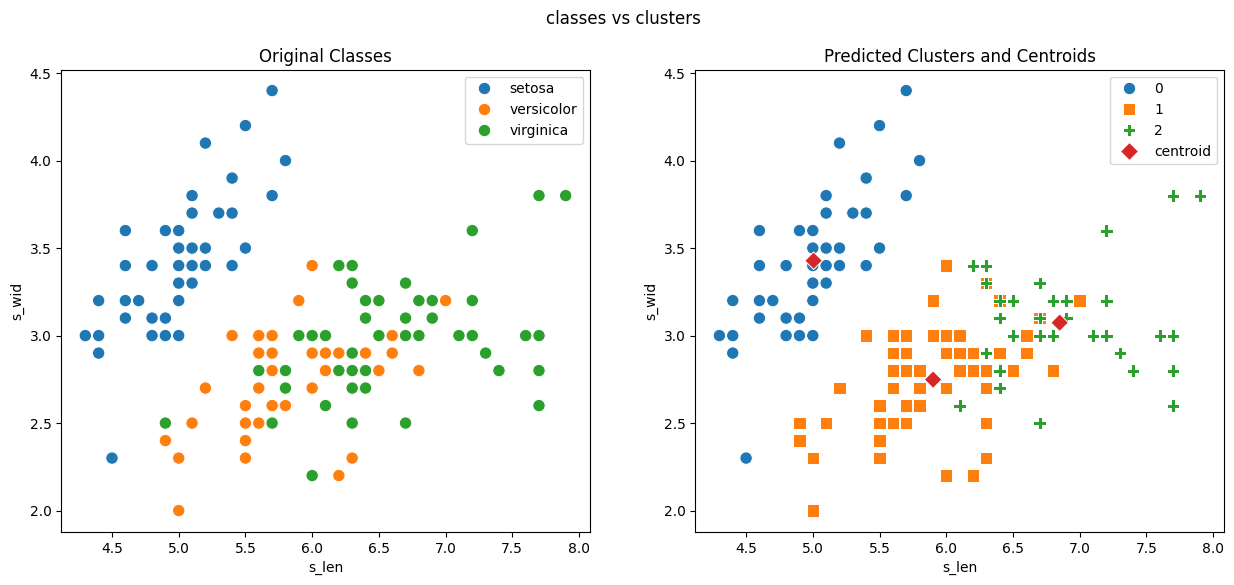

In [6]:
plt.figure(figsize=(15,6))
plt.suptitle("classes vs clusters")
plt.subplot(121)
plt.title("Original Classes")
sns.scatterplot(data=all_df,x="s_len",y="s_wid",hue="species",s=80)
plt.legend(loc="upper right")

plt.subplot(122)
plt.title("Predicted Clusters and Centroids")
sns.scatterplot(
    data=all_df,x="s_len",y="s_wid",
    hue="cluster",style = "cluster",
    markers="osPD",s=80
)
plt.legend(loc="upper right")

plt.show()

#### Part 6 — Hyperparameter tuning with multiple values of $k$

Fit the model for $k=2,3,4,5$. Record both metrics and determine whether they favour the same value of $k$.

In [19]:
sil_coefs = []
distortions = []
# K = np.arange(2, 20,1)
K = [i for i in range(2,10,1)]

# TODO 9: For each k, fit your KMeans class, calculate both metrics,
# print the results, and append them to the lists above.
for k in K:
    kmeans = KMeans(k).fit(train_x)
    sil_coefs.append(silhouette_score(train_x, kmeans.labels))
    distortions.append(distortion(train_x, kmeans.labels, kmeans.centroids))


assert len(sil_coefs) == len(K) and len(distortions) == len(K), \
    "TODO 9: store one value of each metric for every k"

#### Part 7 - Using Elbow method to Find the optimal value of k

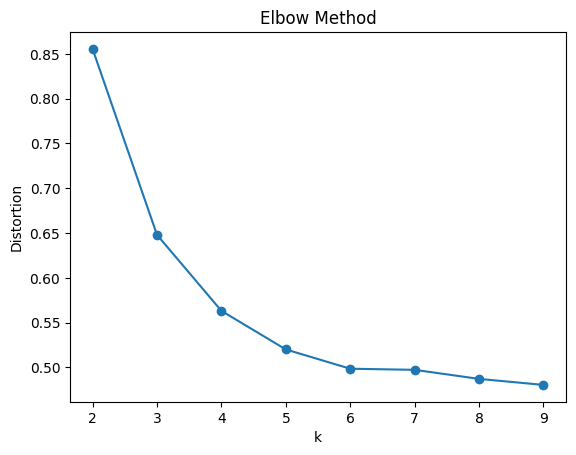

In [20]:
# TODO 10: Plot distortion against k and label both axes.
# Mark each tested value of k on the x-axis.
plt.plot(K, distortions, marker = "o")
plt.xlabel("k")
plt.ylabel("Distortion")
plt.title("Elbow Method")
plt.show()

#### Part 8 -  Implementing K-means clustering with scikit learn

In [9]:
from sklearn.cluster import KMeans as sklKMeans
from sklearn.metrics import silhouette_score as sk_silhouette_score

In [26]:
# TODO 11: Fit scikit-learn's KMeans for k=3.
# For a reproducible comparison, set init="random", n_init=10, and random_state=0.
# Then calculate its silhouette score and distortion.
sil_coefs_sklearn = []
distortions_sklearn = []
for k in K:
  sk_kmeans = sklKMeans(n_clusters = k, init = "random", n_init = 10, random_state = 0).fit(train_x)
  ss = sk_silhouette_score(train_x, sk_kmeans.labels_)
  sil_coefs_sklearn.append(ss)
  dist = distortion(train_x, sk_kmeans.labels_, sk_kmeans.cluster_centers_)
  distortions_sklearn.append(dist)


# TODO 12: Print both metrics to five decimal places and compare them with
# your from-scratch implementation.
print("Difference between scratch implementation and the SK learn implementation")
for i in range(8):
  print(f"k = {K[i]}")
  print(f"Silhouette Score: {sil_coefs_sklearn[i] - sil_coefs[i]}")
  print(f"Distortion: {distortions_sklearn[i] - distortions[i]}")


Difference between scratch implementation and the SK learn implementation
k = 2
Silhouette Score: -0.00398514918073134
Distortion: 2.220446049250313e-16
k = 3
Silhouette Score: -0.16529141940689318
Distortion: 0.0
k = 4
Silhouette Score: -0.2455029039545597
Distortion: -0.005738645681798049
k = 5
Silhouette Score: -0.2646315009269778
Distortion: -0.0103891023997158
k = 6
Silhouette Score: -0.28276480248481883
Distortion: -0.015956733851228422
k = 7
Silhouette Score: -0.4199860893840645
Distortion: -0.053382508872361456
k = 8
Silhouette Score: -0.40358718665970833
Distortion: -0.07536909846938306
k = 9
Silhouette Score: -0.43776284367337714
Distortion: -0.0820192686473567


## b) Clustering using Gaussian Mixture Model(GMM)

### Program 1 — Implementing a GMM from scratch using the Expectation–Maximization algorithm

#### AIM

To implement a Gaussian Mixture Model (GMM) from scratch using the Expectation–Maximization (EM) algorithm and compare two methods for initializing the component means.

#### Formula:

##### Log-likelihood

For $K$ Gaussian components, the observed-data log-likelihood is

$$
\ell(\theta)=\sum_{i=1}^{N}\log\left[\sum_{k=1}^{K}\pi_k\,
\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)\right].
$$

##### Auxiliary function

$$
Q(\theta,\theta^{(t-1)})=
\sum_i\sum_k r_{ik}\log\pi_k+
\sum_i\sum_k r_{ik}\log p(\mathbf{x}_i\mid\theta_k),
$$

where $r_{ik}=p(z_i=k\mid\mathbf{x}_i,\theta^{(t-1)})$ is the responsibility that component $k$ takes for observation $i$.

##### Responsibility (E-step)

$$
r_{ik}=\frac{\pi_k\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_k,\boldsymbol{\Sigma}_k)}
{\sum_{j=1}^{K}\pi_j\,\mathcal{N}(\mathbf{x}_i\mid\boldsymbol{\mu}_j,\boldsymbol{\Sigma}_j)}.
$$

For every observation $i$, the responsibilities must satisfy $\sum_k r_{ik}=1$.

##### Parameter updates (M-step)

Let $N_k=\sum_i r_{ik}$. Then

$$
\pi_k=\frac{N_k}{N},\qquad
\boldsymbol{\mu}_k=\frac{\sum_i r_{ik}\mathbf{x}_i}{N_k},\qquad
\boldsymbol{\Sigma}_k=
\frac{\sum_i r_{ik}(\mathbf{x}_i-\boldsymbol{\mu}_k)(\mathbf{x}_i-\boldsymbol{\mu}_k)^T}{N_k}.
$$

#### EM algorithm

1. Initialize the component weights, means, and covariance matrices.
2. **E-step:** calculate the posterior responsibility of every component for every observation.
3. **M-step:** update the weights, means, and covariance matrices using those responsibilities.
4. Evaluate the log-likelihood and repeat steps 2–3 until its improvement is no greater than the tolerance.

#### Part 1 - Defining the class for GMM

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans as SklKMeans

In [12]:
class GMM:
    def __init__(
        self, n_components: int, n_iters: int, tol: float,
        random_state: int = 0, init_params: str = "random",
        reg_covar: float = 1e-6,
    ):
        self.n_components = n_components
        self.n_iters = n_iters
        self.tol = tol
        self.init_params = init_params
        self.random_state = random_state
        self.reg_covar = reg_covar

    def fit(self, X, plot=False, plot_params=None):
        if plot_params is None:
            plot_params = {}

        m, n = X.shape
        self.X = X
        k = self.n_components

        self.resp = np.zeros((m, k))
        self.weights = np.full(k, 1 / k)

        # TODO 13: Initialize `self.means`.
        # - If init_params == "kmeans", fit SklKMeans and use its centers.
        # - If init_params == "random", select k distinct observations.
        # - Otherwise, raise ValueError for an unsupported method.
        if self.init_params == "kmeans":
            kmeans = SklKMeans(n_clusters = k, random_state = self.random_state).fit(X)
            self.means = kmeans.cluster_centers_
        elif self.init_params == "random":
            rng = np.random.default_rng(self.random_state)
            indices = rng.choice(m, size = k, replace = False)
            self.means = X[indices]
        else:
            raise ValueError("Unsupported initialization method")


        # TODO 14: Initialize every covariance matrix using the covariance of X.
        # Add reg_covar * identity for numerical stability.


        self.covs = np.array([np.cov(X.T) + self.reg_covar * np.identity(n) for _ in range(k)])
        self.converged = False
        self.log_likelihood_trace = []

        if plot:
            fig, ax = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle("GMM using Expectation–Maximization")
            self.draw(ax[0], "Initial components", **plot_params)

        for iteration in range(self.n_iters):
            # TODO 15: Perform one E-step and one M-step.
            self._do_estep(X)
            self._do_mstep(X)


            # TODO 16: Append the current log-likelihood to its trace.
            log_likelihood = self._do_estep(X)
            self.log_likelihood_trace.append(log_likelihood)


            if iteration == 0 and plot:
                self.draw(ax[1], "Components after 1 iteration", **plot_params)

            if iteration > 0:
                old_ll, new_ll = self.log_likelihood_trace[-2:]
                # TODO 17: Stop if the non-negative log-likelihood improvement
                # is no greater than `self.tol`.
                if new_ll - old_ll <= self.tol:
                    self.converged = True
                    break

        self.n_iter_ = iteration + 1

        if plot:
            self.draw(ax[2], f"Components after {self.n_iter_} iterations", **plot_params)
            ax[3].plot(self.log_likelihood_trace, "-o")
            ax[3].set_title("Log-likelihood")
            ax[3].set_xlabel("Iteration")
            plt.show()

        return self

    def _do_estep(self, X):
        # TODO 18: Calculate the unnormalized responsibilities
        # weights[k] * N(X | mean[k], cov[k]) for every component.

        n_samples = X.shape[0]
        resp = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            resp[:, k] = self.weights[k] * multivariate_normal(self.means[k], self.covs[k]).pdf(X)
        # TODO 19: Normalize each row so that it sums to 1, and calculate
        # the total log-likelihood. Use a small lower bound to avoid log(0).
        row_sum = np.sum(resp, axis = 1)
        row_sum = np.maximum(row_sum, 1e-300)
        self.resp = resp / row_sum[:, np.newaxis]
        log_likelihood = np.sum(np.log(row_sum))
        return log_likelihood

    def _do_mstep(self, X):
        # TODO 20: Calculate effective component counts N_k and update weights.
        n_samples, n_features = X.shape
        resp_weights= np.sum(self.resp, axis = 0)
        self.weights = resp_weights / n_samples

        # TODO 21: Update the component means.
        for k in range(self.n_components):
            self.means[k] = np.sum(self.resp[:, k][:, np.newaxis] * X, axis = 0) / resp_weights[k]

        # TODO 22: Update every covariance matrix using the weighted outer
        # products. Add reg_covar * identity to each matrix.
        for k in range(self.n_components):
            diff = X - self.means[k]
            self.covs[k] = ((self.resp[:, k, None]* diff).T @diff/resp_weights[k])
            self.covs[k] += self.reg_covar * np.identity(n_features)

    def predict_proba(self, X):
        # TODO 23 (extension): Return responsibilities without changing the
        # fitted parameters or the stored training responsibilities.
        n_samples = X.shape[0]
        resp = np.zeros((n_samples, self.n_components))
        for k in range(self.n_components):
            resp[:, k] = self.weights[k] * multivariate_normal(self.means[k], self.covs[k]).pdf(X)

        row_sum = np.sum(resp, axis = 1)
        return self.resp


    def predict(self, X):
        # TODO 24 (extension): Return the most probable component for each row.
        return np.argmax(self.predict_proba(X), axis = 1)

    def draw(self, ax, title="", **plot_params):
        # Plot two-dimensional data, component means, and density contours.
        ax.set_title(title)
        ax.scatter(self.X[:, 0], self.X[:, 1], **plot_params)

        delta = 0.05
        x = np.arange(*ax.get_xlim(), delta)
        y = np.arange(*ax.get_ylim(), delta)
        x, y = np.meshgrid(x, y)
        colors = [f"C{(i + 1) % 10}" for i in range(self.n_components)]

        for i in range(self.n_components):
            mean, cov = self.means[i], self.covs[i]
            z = multivariate_normal(mean, cov).pdf(np.dstack([x, y]))
            ax.scatter(mean[0], mean[1], color=colors[i], marker="X", s=100)
            ax.contour(x, y, z, levels=[0.01], colors=colors[i])

#### Part 2 — Generating random data from a Gaussian mixture

The data-generation function is supplied. Read it carefully and identify where the means and positive-semidefinite covariance matrices are created.

In [13]:
def gen_data(k=3, dim=2, points_per_cluster=200, lim=(-10, 10), seed=1):
    rng = np.random.default_rng(seed)
    samples = np.empty((k, points_per_cluster, dim))
    means = rng.uniform(lim[0], lim[1], size=(k, dim))

    for i in range(k):
        A = rng.random((dim, dim + 10))
        cov = A @ A.T
        samples[i] = rng.multivariate_normal(means[i], cov, points_per_cluster)

    X = samples.reshape(-1, dim)

    if dim == 2:
        plt.figure(figsize=(6, 5))
        plt.title("Generated Gaussian-mixture data")
        plt.scatter(X[:, 0], X[:, 1], s=3, alpha=0.4)
        plt.show()

    return X

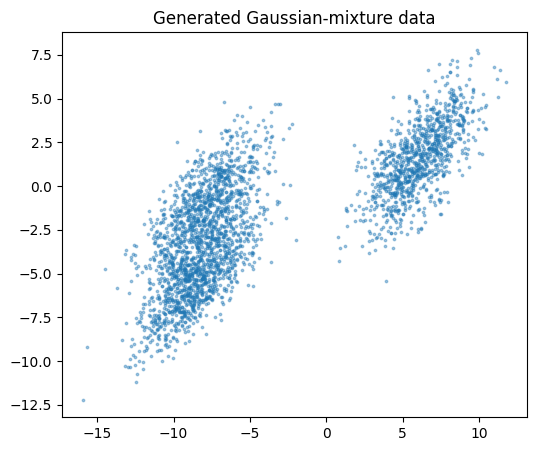

In [14]:
X = gen_data(k=3, dim=2, points_per_cluster=1000, seed=3)

#### Part 3 - Implementing GMM on generated random data

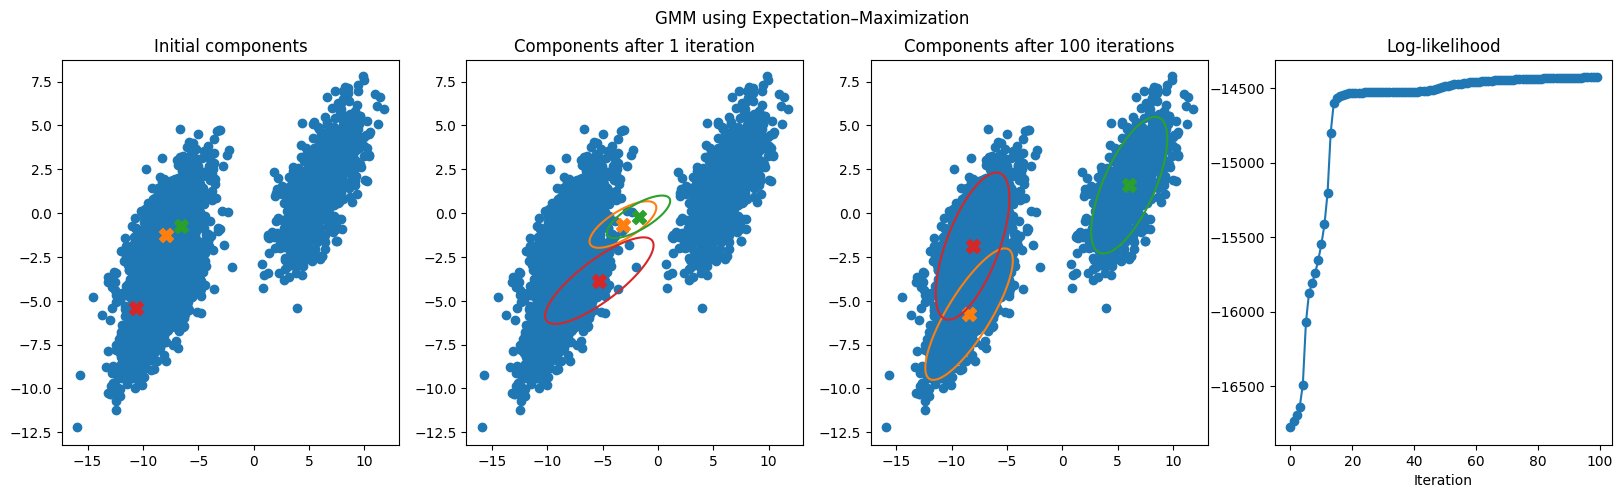

In [15]:
# TODO 25: Create a 3-component GMM with random initialization, fit it to X,
# and display the progress plots. Use n_iters=100, tol=1e-4, random_state=5.
gmm_random = GMM(n_components = 3, n_iters = 100, tol = 1e-4, random_state = 5).fit(X, plot = True)

# After fitting, uncomment these diagnostic checks.
assert np.allclose(gmm_random.weights.sum(), 1.0)
assert np.allclose(gmm_random.resp.sum(axis=1), 1.0)
assert np.all(np.diff(gmm_random.log_likelihood_trace) >= -1e-6)

#### Part 4 - Implementing GMM by using kmeans to initialize means

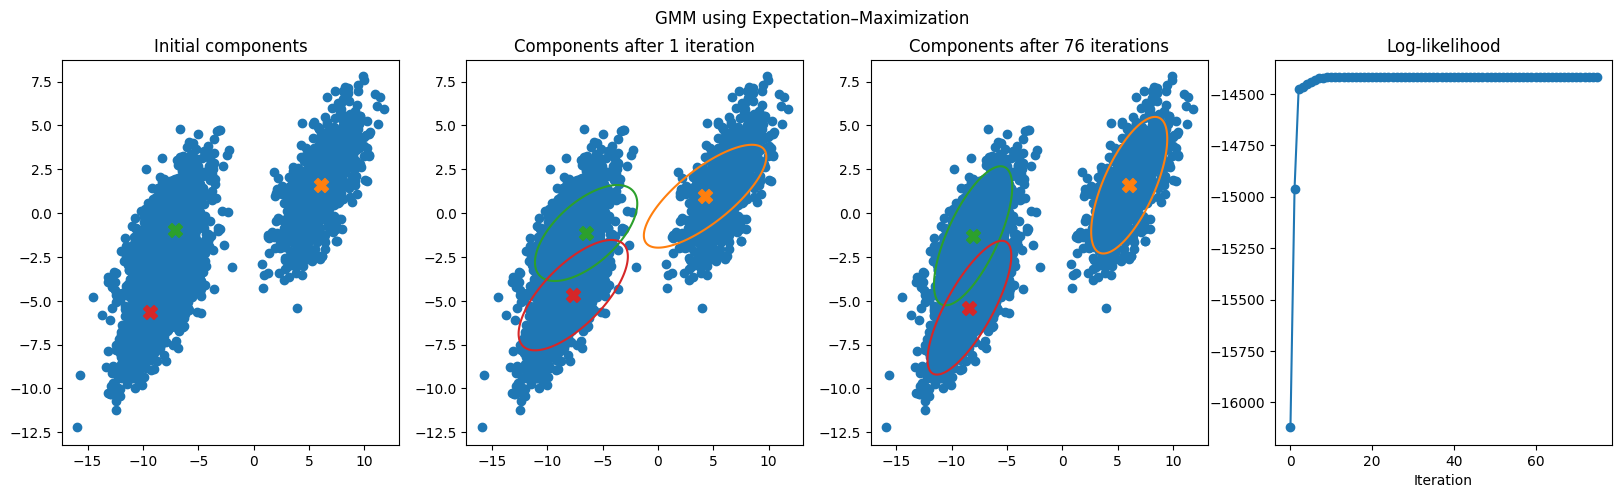

In [16]:
# TODO 26: Repeat the fit with K-means initialization and random_state=1.
gmm_kmeans = GMM(n_components = 3, n_iters = 100, tol = 1e-4, random_state = 1, init_params = "kmeans").fit(X, plot = True)

# TODO 27: Compare the two runs using the final log-likelihood and number of
# iterations. Which initialization converged faster? Did both reach the same
# solution? Write your interpretation in the markdown cell below.

## Results and interpretation

Complete this section after running both algorithms.

1. **Best value of $k$ for Iris:** TODO — report the evidence from the elbow curve and silhouette scores.
2. **From-scratch vs scikit-learn K-means:** TODO — compare the two metric values and comment on initialization.
3. **Random vs K-means initialization for GMM:** TODO — compare convergence speed and final log-likelihood.
4. **K-means vs GMM:** TODO — explain one important difference between hard assignments and probabilistic responsibilities.
5. **Chemistry connection:** TODO — give one chemical dataset for which GMM clustering could be more informative than K-means (for example, overlapping conformer populations or spectra).

Answers:
1.
Based on the elbow curve and silhouette score, the optimal number of clusters is k = 6. At this threshold, the model's distortion has already experienced its most substantial drop, meaning the addition of more clusters would only provide diminishing returns.

2.
When k = 2, the custom (scratch) implementation and the Scikit-learn model yield nearly identical results, with only negligible differences in silhouette scores and fractional variances in distortion. However, as k increases, the performance gap between the two implementations gradually widens. This divergence highlights that while the custom model mirrors Scikit-learn at lower values of k, larger cluster counts expose the inherent sensitivity of the K-Means algorithm to initial centroid placement.

3.
Using K-means for initialization resulted in much faster convergence compared to random initialization. The K-means-initialized model converged in just 76 iterations, while the randomly initialized model failed to converge within the 100-iteration limit. Since both methods ultimately reached a similar final log-likelihood, they essentially found the same solution. K-means accelerates this process by providing highly accurate initial estimates for the component means, giving the Expectation-Maximization (EM) algorithm a strong head start.

4.
K-means relies on hard assignments, meaning every data point is strictly categorized into exactly one cluster (i.e., a 100% assignment to a single group). In contrast, GMM uses probabilistic responsibilities (soft assignments), allowing a single data point to belong to multiple clusters simultaneously with varying probabilities (e.g., a 70% chance of belonging to Cluster A and a 30% chance for Cluster B). Ultimately, K-means forces a rigid classification, whereas GMM effectively models uncertainty and overlapping data distributions.

5.
An excellent chemical dataset for GMM clustering would be molecular spectra—such as NMR or IR spectroscopy—derived from a mixture of chemical species. Because compounds frequently exhibit overlapping spectral peaks, a single reading often contains signals from multiple components. GMM outperforms K-means in this scenario because it uses probabilistic memberships rather than forcing a strict, single-cluster assignment. For instance, when analyzing NMR data from a mixture of conformers, GMM can accurately estimate the probability of a sample belonging to each conformer's population, capturing the nuanced overlap that K-means would ignore.